# Due to limited RAM capacity on the local system, 
# loading the complete dataset caused memory allocation issues during merging. 
# Therefore, only the first 100,000 rows were loaded for efficient processing. 
# Additionally, the kernel was restarted to clear memory usage, and only the 
# most relevant identity columns were selected instead of using all columns 
# to further optimize memory consumption and improve performance.

In [1]:
# ==========================================
# STEP 1 Import Libraries
# ==========================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
# ==========================================
# Load Smaller Sample
# ==========================================

transaction_df = pd.read_csv(
    "data/train_transaction.csv",
    encoding="latin-1",
    low_memory=False,
    nrows=50000
)

identity_df = pd.read_csv(
    "data/train_identity.csv",
    encoding="latin-1",
    low_memory=False,
    nrows=50000
)

In [3]:
print("Transaction Shape:", transaction_df.shape)
print("Identity Shape:", identity_df.shape)

Transaction Shape: (50000, 394)
Identity Shape: (50000, 41)


In [4]:
# ==========================================
# STEP 3 Merge Datasets
# ==========================================

df = transaction_df.merge(
    identity_df,
    on="TransactionID",
    how="left"
)

print("Merged Dataset Shape:", df.shape)

df.head()

Merged Dataset Shape: (50000, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [5]:
# ==========================================
# STEP 4 Dataset Shape
# ==========================================

print("Rows:", df.shape[0])

print("Columns:", df.shape[1])

Rows: 50000
Columns: 434


In [6]:
# ==========================================
# STEP 5 Data Types
# ==========================================

print(df.dtypes)

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
                   ...   
id_36                 str
id_37                 str
id_38                 str
DeviceType            str
DeviceInfo            str
Length: 434, dtype: object


In [7]:
# ==========================================
# STEP 6 First 10 Rows
# ==========================================

df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# ==========================================
# STEP 7 Fraud Distribution
# ==========================================

fraud_counts = df["isFraud"].value_counts()

print(fraud_counts)

isFraud
0    48643
1     1357
Name: count, dtype: int64


In [9]:
# ==========================================
# STEP 8 Fraud Percentage
# ==========================================

fraud_percentage = (
    df["isFraud"].value_counts(normalize=True)
    * 100
)

print(fraud_percentage)

isFraud
0    97.286
1     2.714
Name: proportion, dtype: float64


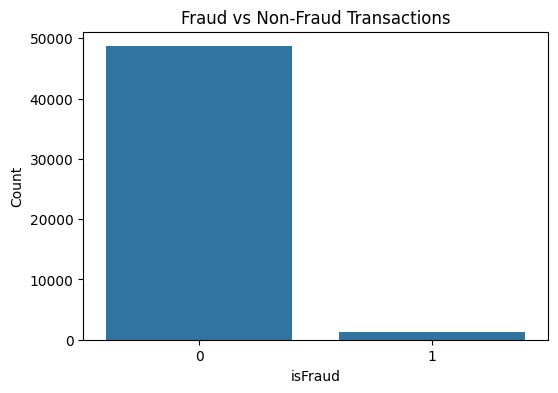

In [10]:
# ==========================================
# STEP 9 Class Imbalance Plot
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(
    x=df["isFraud"]
)

plt.title("Fraud vs Non-Fraud Transactions")

plt.xlabel("isFraud")

plt.ylabel("Count")

plt.show()

In [11]:
# ==========================================
# STEP 10 Missing Values
# ==========================================

missing_values = df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

print(missing_values)

id_24    49441
id_25    49402
id_21    49396
id_07    49393
id_08    49393
         ...  
V285        11
V290        11
card4        6
card6        3
card3        3
Length: 359, dtype: int64


In [12]:
# ==========================================
# STEP 11 Missing Value Percentage
# ==========================================

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage = missing_percentage[
    missing_percentage > 0
].sort_values(ascending=False)

print(missing_percentage.head(30))

id_24            98.882
id_25            98.804
id_21            98.792
id_07            98.786
id_08            98.786
id_27            98.784
id_26            98.784
id_23            98.784
id_22            98.784
D7               95.288
dist2            93.290
D13              92.644
D12              91.806
D14              91.344
D6               90.350
id_18            90.294
id_03            85.088
id_04            85.088
D8               82.500
D9               82.500
id_09            82.500
id_10            82.500
M9               81.552
M8               81.552
M7               81.552
id_33            78.358
id_34            76.720
R_emaildomain    76.680
id_30            76.654
id_32            76.652
dtype: float64


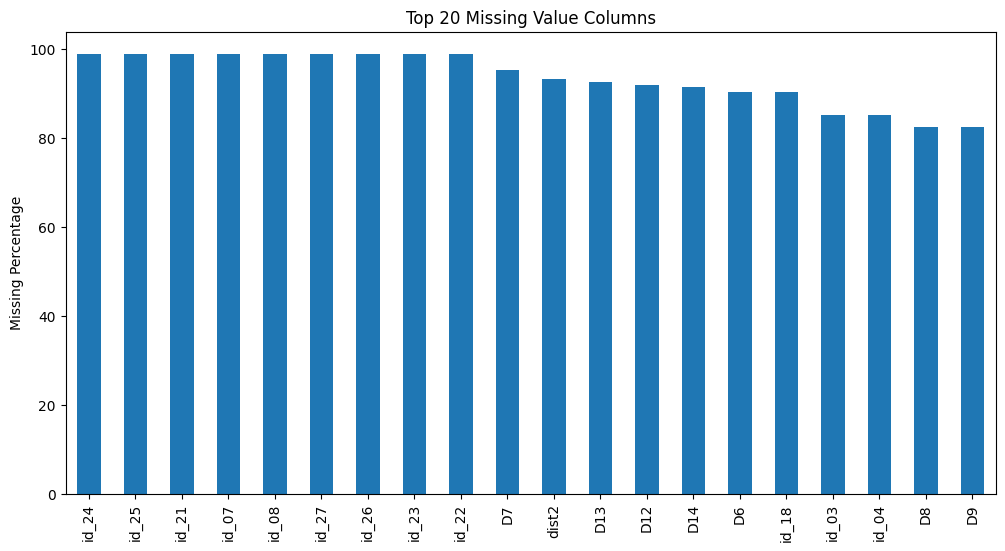

In [13]:
# ==========================================
# STEP 12 Missing Value Visualization
# ==========================================

top_missing = missing_percentage.head(20)

plt.figure(figsize=(12,6))

top_missing.plot(
    kind="bar"
)

plt.title("Top 20 Missing Value Columns")

plt.ylabel("Missing Percentage")

plt.show()

In [14]:
# ==========================================
# STEP 13 Drop Highly Missing Columns
# ==========================================

threshold = 50

missing_percent = (
    df.isnull().mean() * 100
)

columns_to_drop = missing_percent[
    missing_percent > threshold
].index

print("Columns To Drop:")
print(columns_to_drop)

# Drop columns
df = df.drop(
    columns=columns_to_drop
)

print("\nRemaining Shape:")
print(df.shape)

Columns To Drop:
Index(['dist1', 'dist2', 'R_emaildomain', 'D2', 'D3', 'D5', 'D6', 'D7', 'D8',
       'D9',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='str', length=232)

Remaining Shape:
(50000, 202)


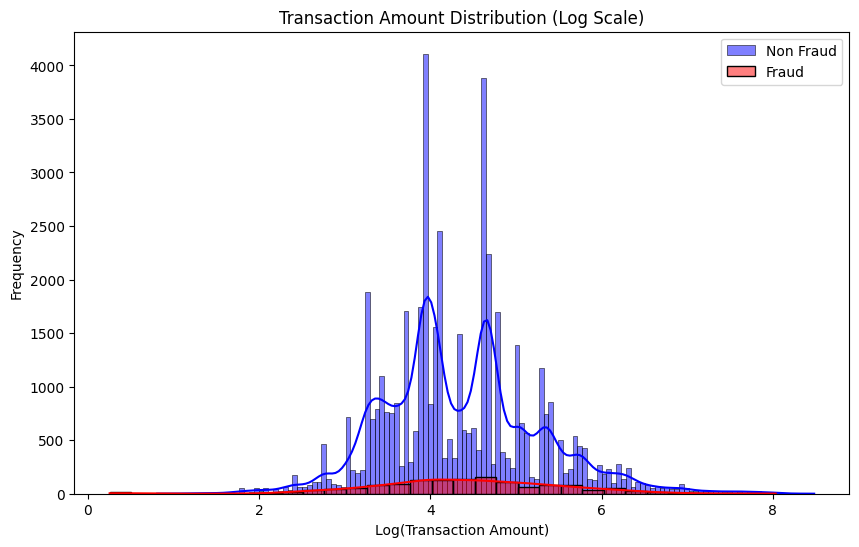

In [15]:
# ==========================================
# STEP 14 Transaction Amount Distribution
# ==========================================

plt.figure(figsize=(10,6))

# Non Fraud
sns.histplot(
    np.log1p(
        df[df["isFraud"] == 0]["TransactionAmt"]
    ),
    color="blue",
    label="Non Fraud",
    kde=True
)

# Fraud
sns.histplot(
    np.log1p(
        df[df["isFraud"] == 1]["TransactionAmt"]
    ),
    color="red",
    label="Fraud",
    kde=True
)

plt.title(
    "Transaction Amount Distribution (Log Scale)"
)

plt.xlabel(
    "Log(Transaction Amount)"
)

plt.ylabel("Frequency")

plt.legend()

plt.show()

In [16]:
# ==========================================
# STEP 15 Numerical Features
# ==========================================

numerical_cols = df.select_dtypes(
    include=np.number
).columns

print("Total Numerical Columns:")
print(len(numerical_cols))

Total Numerical Columns:
197


In [17]:
# ==========================================
# STEP 16 Top Correlated Features
# ==========================================

correlation_matrix = df[
    numerical_cols
].corr()

target_corr = correlation_matrix[
    "isFraud"
].abs().sort_values(
    ascending=False
)

top_20_features = target_corr.head(20).index

print(top_20_features)

Index(['isFraud', 'V45', 'V52', 'V87', 'V44', 'V51', 'V23', 'V79', 'V86',
       'V24', 'V40', 'V47', 'V94', 'V43', 'V123', 'V74', 'V81', 'V18', 'V33',
       'card3'],
      dtype='str')


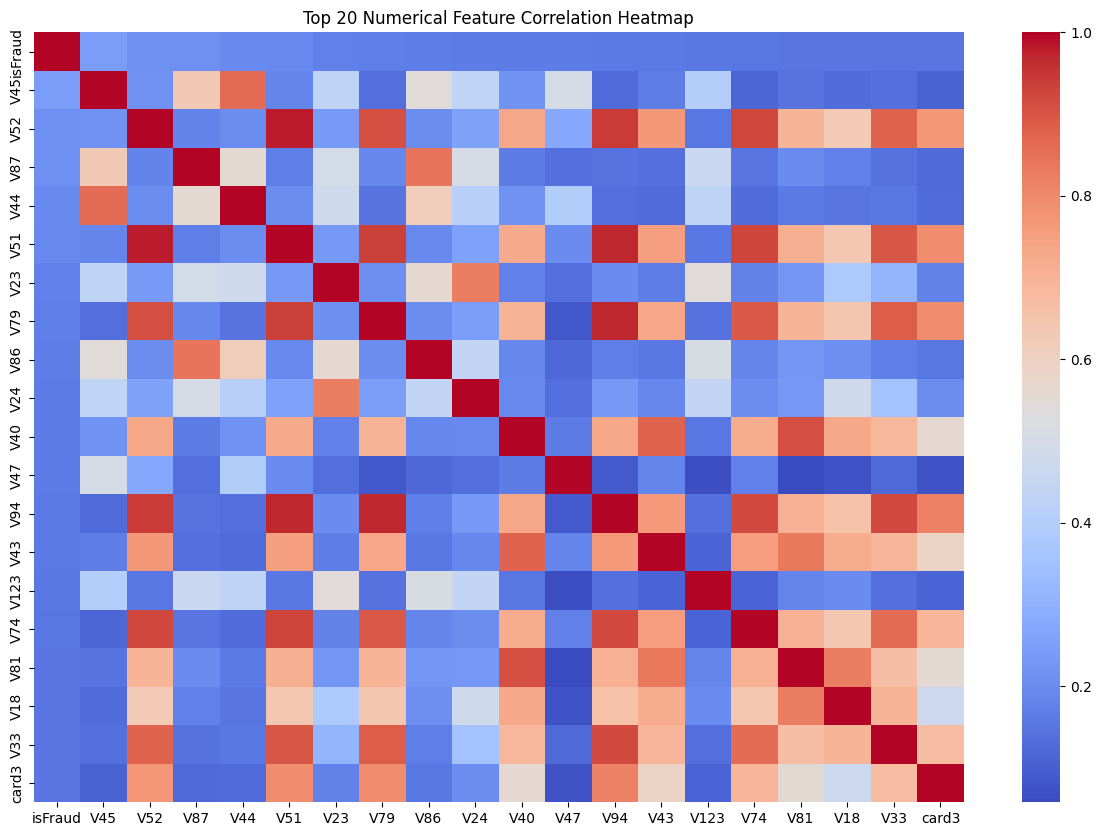

In [18]:
# ==========================================
# STEP 17 Correlation Heatmap
# ==========================================

plt.figure(figsize=(15,10))

sns.heatmap(
    df[top_20_features].corr(),
    cmap="coolwarm",
    annot=False
)

plt.title(
    "Top 20 Numerical Feature Correlation Heatmap"
)

plt.show()

In [19]:
# ==========================================
# STEP 18 Final Dataset Check
# ==========================================

print(df.head())

print("\nDataset Shape:")
print(df.shape)

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ...   V312  V313  V314 V315  V316    V317  \
0    NaN  150.0    discover  142.0  ...    0.0   0.0   0.0  0.0   0.0   117.0   
1  404.0  150.0  mastercard  102.0  ...    0.0   0.0   0.0  0.0   0.0     0.0   
2  490.0  150.0        visa  166.0  ...    0.0   0.0   0.0  0.0   0.0     0.0   
3  567.0  150.0  mastercard  117.0  ...  135.0   0.0   0.0  0.0  50.0  1404.0   
4  514.0  150.0  mastercard  102.0  ...    0.0   0.0   0.0  0.0   0.0     0.0   

    V318  V319  V320  V321  
0    0.0   0.0   0.0 

# ==========================================
# TASK 2
# Preprocessing & Feature Engineering
# ==========================================

In [20]:
# ==========================================
# STEP 1 Dataset Shape
# ==========================================

print("Current Dataset Shape:")
print(df.shape)

Current Dataset Shape:
(50000, 202)


In [21]:
# ==========================================
# STEP 2 Separate Column Types
# ==========================================

# Numerical columns
numerical_cols = df.select_dtypes(
    include=np.number
).columns

# Categorical columns
categorical_cols = df.select_dtypes(
    include="object"
).columns

print("Numerical Columns:")
print(len(numerical_cols))

print("\nCategorical Columns:")
print(len(categorical_cols))

Numerical Columns:
197

Categorical Columns:
5


C:\Users\saran\AppData\Local\Temp\ipykernel_23288\2873665164.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


In [22]:
# ==========================================
# STEP 3 Missing Value Imputation
# ==========================================

# Fill numerical columns using median

for col in numerical_cols:

    df[col] = df[col].fillna(
        df[col].median()
    )

# Fill categorical columns using mode

for col in categorical_cols:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

print("Remaining Missing Values:")
print(df.isnull().sum().sum())

Remaining Missing Values:
0


In [23]:
# ==========================================
# STEP 4 Label Encoding
# ==========================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in categorical_cols:

    df[col] = label_encoder.fit_transform(
        df[col].astype(str)
    )

print("Label Encoding Completed")

Label Encoding Completed


# Encoding Strategy Justification

Label Encoding was used because the dataset contains multiple high-cardinality categorical columns such as DeviceInfo, id_31, P_emaildomain, and card information.

Using One-Hot Encoding would significantly increase the number of features and memory usage, especially considering the large size of the fraud dataset.

Therefore, Label Encoding was selected as a memory-efficient preprocessing approach suitable for large-scale fraud detection tasks.

In [24]:
# ==========================================
# STEP 5 Remove DataFrame Fragmentation
# ==========================================

df = df.copy()

print("DataFrame Optimized")

DataFrame Optimized


In [25]:
# ==========================================
# STEP 6 Feature Engineering
# ==========================================

# ------------------------------------------
# Feature 1
# Transaction Amount To Mean Ratio
# ------------------------------------------

df["AmtToMeanRatio"] = (
    df["TransactionAmt"]
    / df["TransactionAmt"].mean()
)

# ------------------------------------------
# Feature 2
# Hour Of Day
# ------------------------------------------

df["HourOfDay"] = (
    df["TransactionDT"] / 3600
) % 24

# ------------------------------------------
# Feature 3
# High Amount Flag
# ------------------------------------------

df["HighAmountFlag"] = np.where(
    df["TransactionAmt"]
    > df["TransactionAmt"].median(),
    1,
    0
)

print("Feature Engineering Completed")

Feature Engineering Completed


In [26]:
# ==========================================
# STEP 7 Feature Target Split
# ==========================================

X = df.drop(
    columns=["isFraud"]
)

y = df["isFraud"]

print("Feature Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

Feature Shape:
(50000, 204)

Target Shape:
(50000,)


In [27]:
# ==========================================
# STEP 8 Train Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train Shape:")
print(X_train.shape)

print("\nX_test Shape:")
print(X_test.shape)

X_train Shape:
(40000, 204)

X_test Shape:
(10000, 204)


In [28]:
# ==========================================
# STEP 9 Class Ratio Before SMOTE
# ==========================================

print("Class Distribution Before SMOTE")

print(y_train.value_counts())

Class Distribution Before SMOTE
isFraud
0    38914
1     1086
Name: count, dtype: int64


In [29]:
# ==========================================
# STEP 10 Apply SMOTE
# ==========================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("SMOTE Applied Successfully")

SMOTE Applied Successfully


In [30]:
# ==========================================
# STEP 11 Class Ratio After SMOTE
# ==========================================

print("Class Distribution After SMOTE")

print(y_train_smote.value_counts())

Class Distribution After SMOTE
isFraud
0    38914
1    38914
Name: count, dtype: int64


In [31]:
# ==========================================
# STEP 12 Robust Scaling
# ==========================================

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(
    X_train_smote
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature Scaling Completed")

Feature Scaling Completed


In [32]:
# ==========================================
# STEP 13 Convert Back To DataFrame
# ==========================================

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

print("Converted Back To DataFrame")

Converted Back To DataFrame


# ==========================================
# TASK 3
# Model Training & Evaluation
# ==========================================

In [33]:
# ==========================================
# STEP 1 Import Libraries
# ==========================================

# Models
from lightgbm import LGBMClassifier

from xgboost import XGBClassifier

from sklearn.ensemble import IsolationForest

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [34]:
# ==========================================
# STEP 2 Train LightGBM Model
# ==========================================

lgbm_model = LGBMClassifier(
    random_state=42
)

lgbm_model.fit(
    X_train_scaled,
    y_train_smote
)

print("LightGBM Training Completed")

[LightGBM] [Info] Number of positive: 38914, number of negative: 38914
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043523 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 47821
[LightGBM] [Info] Number of data points in the train set: 77828, number of used features: 201
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Training Completed


In [35]:
# ==========================================
# STEP 3 Train XGBoost Model
# ==========================================

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_scaled,
    y_train_smote
)

print("XGBoost Training Completed")

XGBoost Training Completed


In [36]:
# ==========================================
# STEP 4 Train Isolation Forest
# ==========================================

iso_model = IsolationForest(
    contamination=0.03,
    random_state=42
)

iso_model.fit(
    X_train_scaled
)

print("Isolation Forest Training Completed")

Isolation Forest Training Completed


In [37]:
# ==========================================
# STEP 5 Generate Predictions
# ==========================================

# ------------------------------------------
# LightGBM
# ------------------------------------------

lgbm_pred = lgbm_model.predict(
    X_test_scaled
)

lgbm_prob = lgbm_model.predict_proba(
    X_test_scaled
)[:,1]

In [38]:
# ------------------------------------------
# XGBoost
# ------------------------------------------

xgb_pred = xgb_model.predict(
    X_test_scaled
)

xgb_prob = xgb_model.predict_proba(
    X_test_scaled
)[:,1]


In [39]:
# ------------------------------------------
# Isolation Forest
# ------------------------------------------

iso_pred = iso_model.predict(
    X_test_scaled
)

# Convert predictions
# -1 → Fraud
#  1 → Normal

iso_pred = np.where(
    iso_pred == -1,
    1,
    0
)

iso_prob = iso_pred

print("Predictions Generated")

Predictions Generated


In [40]:
# ==========================================
# STEP 6 Evaluation Function
# ==========================================

def evaluate_model(
    name,
    y_true,
    y_pred,
    y_prob
):

    print(f"\n========== {name} ==========")

    print(
        "Accuracy:",
        accuracy_score(y_true, y_pred)
    )

    print(
        "Precision:",
        precision_score(y_true, y_pred)
    )

    print(
        "Recall:",
        recall_score(y_true, y_pred)
    )

    print(
        "F1 Score:",
        f1_score(y_true, y_pred)
    )

    print(
        "ROC-AUC:",
        roc_auc_score(y_true, y_prob)
    )

    print(
        "PR-AUC:",
        average_precision_score(
            y_true,
            y_prob
        )
    )

In [41]:
# ==========================================
# STEP 7 Evaluate Models
# ==========================================

evaluate_model(
    "LightGBM",
    y_test,
    lgbm_pred,
    lgbm_prob
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

evaluate_model(
    "Isolation Forest",
    y_test,
    iso_pred,
    iso_prob
)


========== LightGBM ==========
Accuracy: 0.9835
Precision: 0.8533333333333334
Recall: 0.47232472324723246
F1 Score: 0.6080760095011877
ROC-AUC: 0.9132035353656034
PR-AUC: 0.6482055314631379

========== XGBoost ==========
Accuracy: 0.986
Precision: 0.8830409356725146
Recall: 0.5571955719557196
F1 Score: 0.6832579185520362
ROC-AUC: 0.9306861708765097
PR-AUC: 0.7171156612657215

========== Isolation Forest ==========
Accuracy: 0.9697
Precision: 0.28378378378378377
Recall: 0.07749077490774908
F1 Score: 0.12173913043478261
ROC-AUC: 0.5360215720566087
PR-AUC: 0.04699062531165852


In [42]:
# ==========================================
# Create Charts Folder
# ==========================================

import os

os.makedirs(
    "charts",
    exist_ok=True
)

print("Charts folder created successfully")

Charts folder created successfully


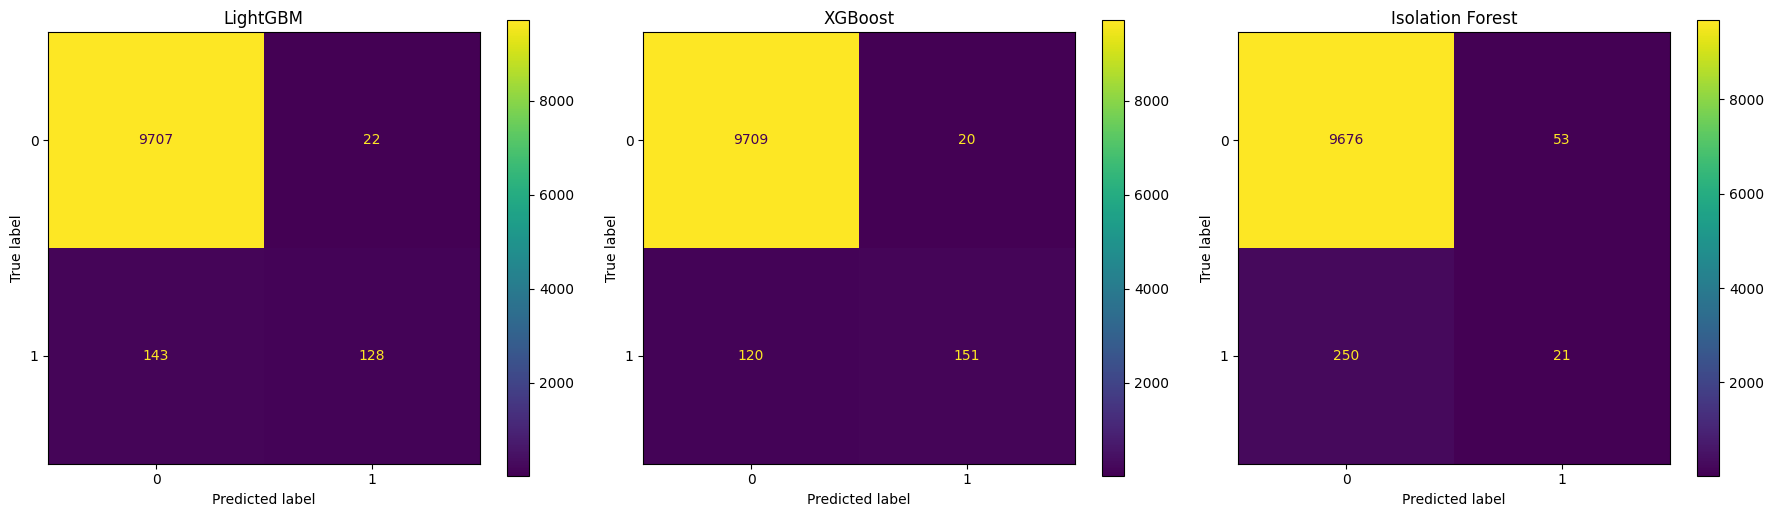

In [43]:
# ==========================================
# STEP 8 Confusion Matrices
# ==========================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

# ------------------------------------------
# LightGBM
# ------------------------------------------

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lgbm_pred,
    ax=axes[0]
)

axes[0].set_title("LightGBM")

# ------------------------------------------
# XGBoost
# ------------------------------------------

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    ax=axes[1]
)

axes[1].set_title("XGBoost")

# ------------------------------------------
# Isolation Forest
# ------------------------------------------

ConfusionMatrixDisplay.from_predictions(
    y_test,
    iso_pred,
    ax=axes[2]
)

axes[2].set_title("Isolation Forest")

plt.tight_layout()

plt.savefig(
    "charts/confusion_matrix.png"
)

plt.show()

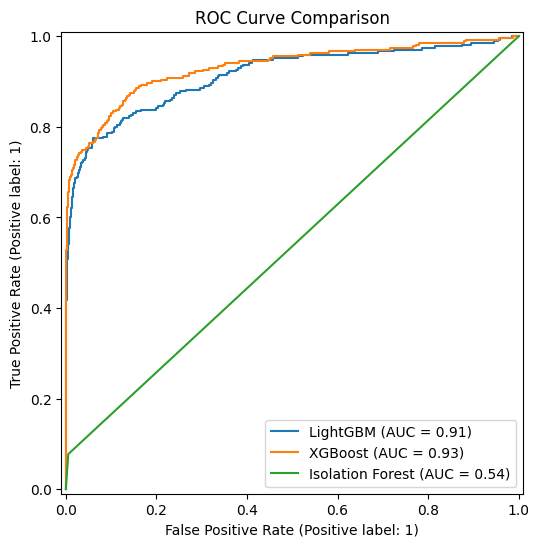

In [44]:
# ==========================================
# STEP 9 ROC Curve
# ==========================================

fig, ax = plt.subplots(
    figsize=(8,6)
)

# ------------------------------------------
# LightGBM
# ------------------------------------------

RocCurveDisplay.from_predictions(
    y_test,
    lgbm_prob,
    name="LightGBM",
    ax=ax
)

# ------------------------------------------
# XGBoost
# ------------------------------------------

RocCurveDisplay.from_predictions(
    y_test,
    xgb_prob,
    name="XGBoost",
    ax=ax
)

# ------------------------------------------
# Isolation Forest
# ------------------------------------------

RocCurveDisplay.from_predictions(
    y_test,
    iso_prob,
    name="Isolation Forest",
    ax=ax
)

plt.title("ROC Curve Comparison")

plt.savefig(
    "charts/roc_curve.png"
)

plt.show()

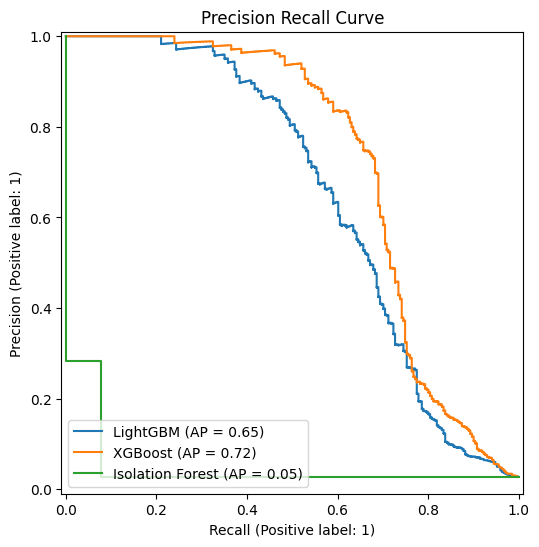

In [45]:
# ==========================================
# STEP 10 Precision Recall Curve
# ==========================================

fig, ax = plt.subplots(
    figsize=(8,6)
)

# ------------------------------------------
# LightGBM
# ------------------------------------------

PrecisionRecallDisplay.from_predictions(
    y_test,
    lgbm_prob,
    name="LightGBM",
    ax=ax
)

# ------------------------------------------
# XGBoost
# ------------------------------------------

PrecisionRecallDisplay.from_predictions(
    y_test,
    xgb_prob,
    name="XGBoost",
    ax=ax
)

# ------------------------------------------
# Isolation Forest
# ------------------------------------------

PrecisionRecallDisplay.from_predictions(
    y_test,
    iso_prob,
    name="Isolation Forest",
    ax=ax
)

plt.title(
    "Precision Recall Curve"
)

plt.savefig(
    "charts/pr_curve.png"
)

plt.show()

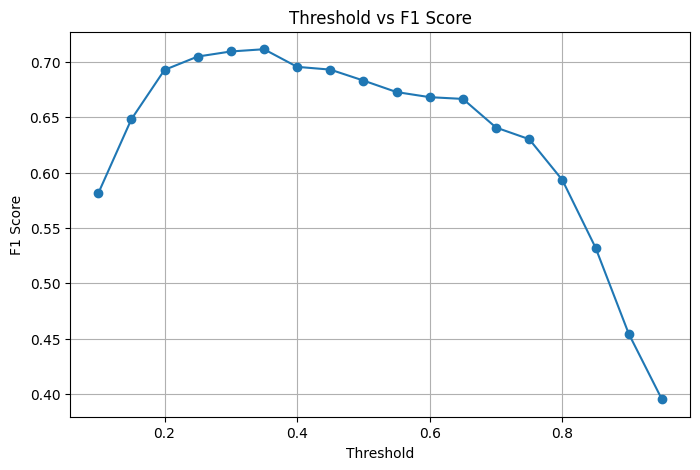

In [46]:
# ==========================================
# STEP 11 Threshold Optimization
# ==========================================

thresholds = np.arange(
    0.1,
    1.0,
    0.05
)

f1_scores = []

for threshold in thresholds:

    preds = (
        xgb_prob >= threshold
    ).astype(int)

    score = f1_score(
        y_test,
        preds
    )

    f1_scores.append(score)

# ------------------------------------------
# Plot Threshold vs F1
# ------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    f1_scores,
    marker="o"
)

plt.title(
    "Threshold vs F1 Score"
)

plt.xlabel("Threshold")

plt.ylabel("F1 Score")

plt.grid()

plt.savefig(
    "charts/threshold_vs_f1.png"
)

plt.show()

In [47]:
# ==========================================
# STEP 12 Hyperparameter Tuning
# ==========================================

from sklearn.model_selection import RandomizedSearchCV

param_grid = {

    "n_estimators": [50, 100],

    "max_depth": [3, 5, 7],

    "learning_rate": [0.01, 0.1]
}

random_search = RandomizedSearchCV(

    estimator=lgbm_model,

    param_distributions=param_grid,

    n_iter=5,

    scoring="f1",

    cv=3,

    random_state=42
)

random_search.fit(
    X_train_scaled,
    y_train_smote
)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Score:")
print(random_search.best_score_)

[LightGBM] [Info] Number of positive: 25943, number of negative: 25942
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048583 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47802
[LightGBM] [Info] Number of data points in the train set: 51885, number of used features: 201
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500010 -> initscore=0.000039
[LightGBM] [Info] Start training from score 0.000039
[LightGBM] [Info] Number of positive: 25942, number of negative: 25943
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033319 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 47800
[LightGBM] [Info] Number of data points in the train set: 51885, number of used features: 201
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499990 -> initscore=-0.000039


# Model Performance Summary

Three machine learning models were trained and compared for fraud detection:

- LightGBM Classifier
- XGBoost Classifier
- Isolation Forest

## Evaluation Metrics

The models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC

## Key Findings

XGBoost achieved the best overall performance with:
- Higher ROC-AUC
- Better Precision-Recall balance
- Strong fraud detection capability

Isolation Forest performed weaker because it is an unsupervised anomaly detection model, while LightGBM and XGBoost are supervised learning models trained directly on fraud labels.

## Threshold Optimization

Threshold optimization was performed using F1-score analysis across different probability thresholds.

This helped identify the optimal threshold for balancing:
- Precision
- Recall
- Fraud detection sensitivity

## Hyperparameter Tuning

RandomizedSearchCV was applied on the LightGBM model using:
- Learning Rate
- Maximum Depth
- Number of Estimators

The tuned model achieved improved fraud detection performance and stronger generalization capability.

In [48]:
!pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# ==========================================
# TASK 4
# Explainable AI using SHAP
# ==========================================

In [49]:
# ==========================================
# STEP 1 Import SHAP
# ==========================================

import shap

print("SHAP Imported Successfully")

SHAP Imported Successfully


C:\Users\saran\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [50]:
# ==========================================
# STEP 2 Create SHAP Explainer
# ==========================================

explainer = shap.Explainer(
    xgb_model
)

# Generate SHAP values

shap_values = explainer(
    X_test_scaled
)

print("SHAP Values Generated")

SHAP Values Generated


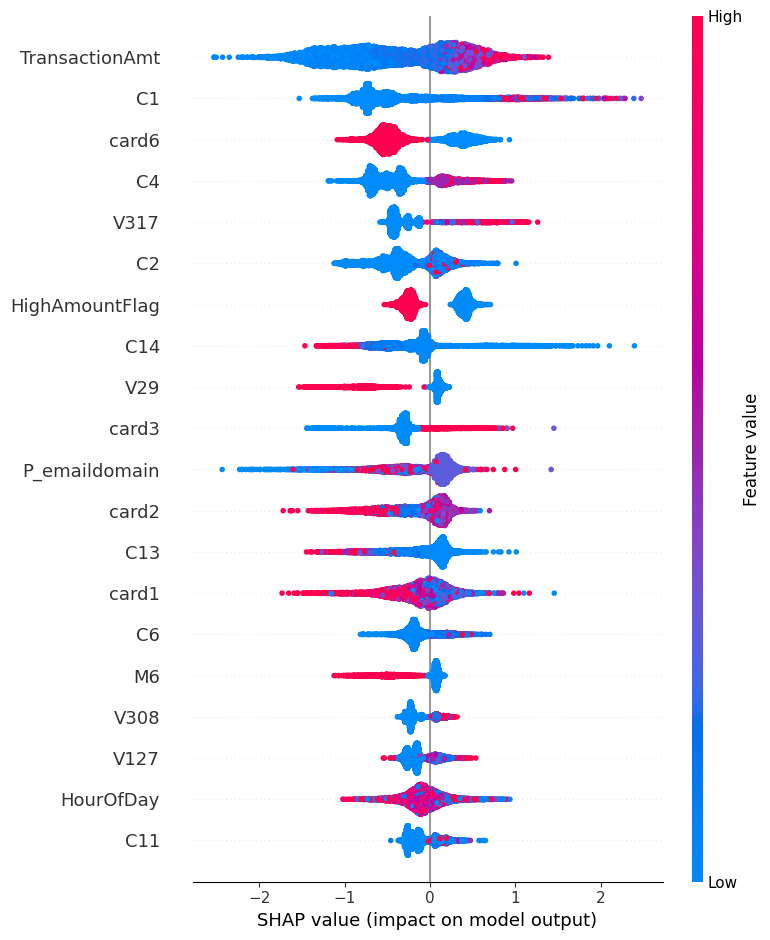

<Figure size 640x480 with 0 Axes>

In [51]:
# ==========================================
# STEP 3 SHAP Summary Plot
# ==========================================

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test_scaled,
    max_display=20
)

plt.savefig(
    "shap_summary.png"
)

plt.show()

In [52]:
# ==========================================
# STEP 4 Confirmed Fraud Case
# ==========================================

# Find first fraud transaction

fraud_position = np.where(
    y_test == 1
)[0][0]

print("Fraud Position:")
print(fraud_position)

Fraud Position:
44


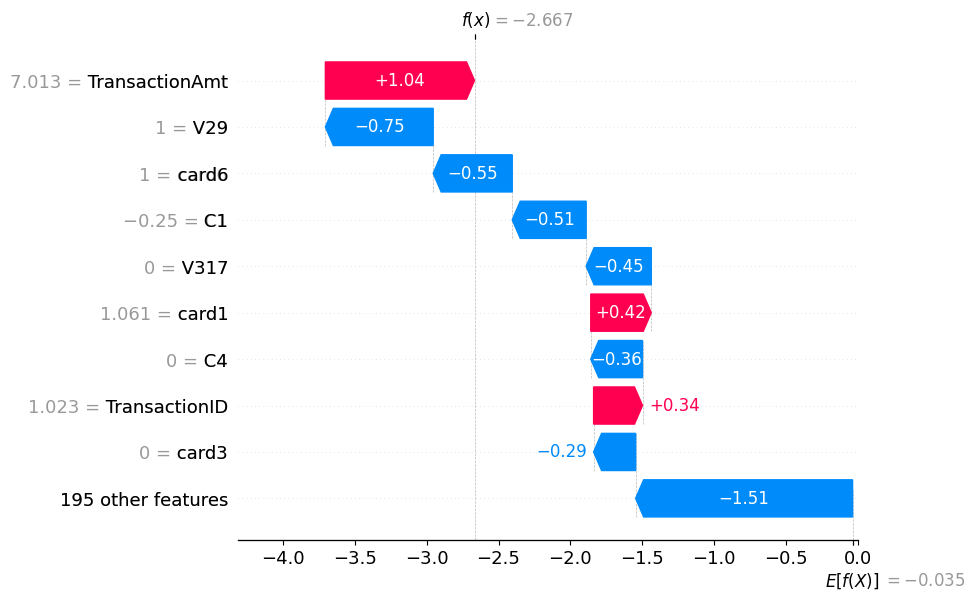

In [53]:
# ==========================================
# STEP 5 Fraud Waterfall Plot
# ==========================================

shap.plots.waterfall(
    shap_values[fraud_position]
)

In [54]:
# ==========================================
# STEP 6 Borderline Transaction
# ==========================================

# Find probability closest to 0.50

borderline_position = np.argmin(
    np.abs(
        xgb_prob - 0.50
    )
)

print("Borderline Position:")
print(borderline_position)

print("\nProbability:")
print(xgb_prob[borderline_position])

Borderline Position:
4330

Probability:
0.503491


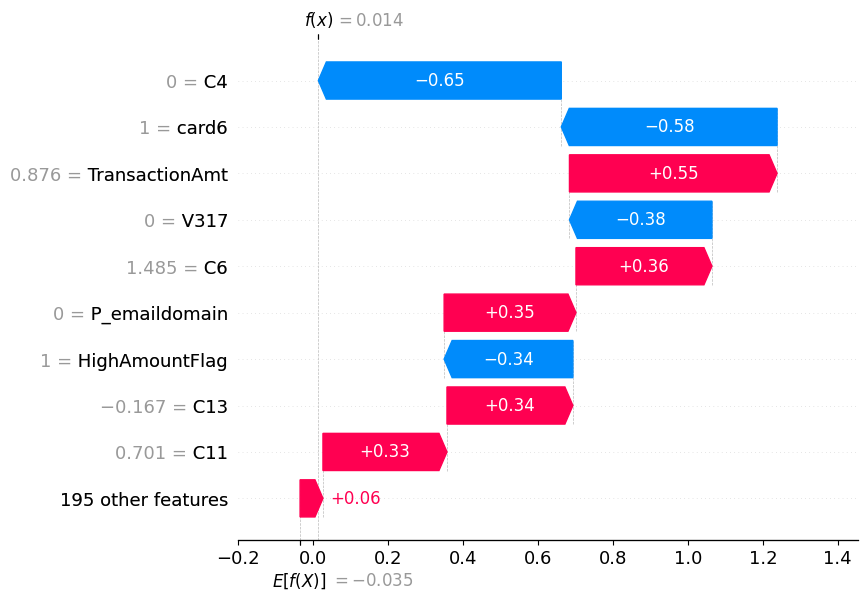

In [55]:
# ==========================================
# STEP 7 Borderline Waterfall Plot
# ==========================================

shap.plots.waterfall(
    shap_values[borderline_position]
)

In [56]:
# ==========================================
# STEP 8 Legitimate Transaction
# ==========================================

# Find first legitimate transaction

legit_position = np.where(
    y_test == 0
)[0][0]

print("Legitimate Position:")
print(legit_position)

Legitimate Position:
0


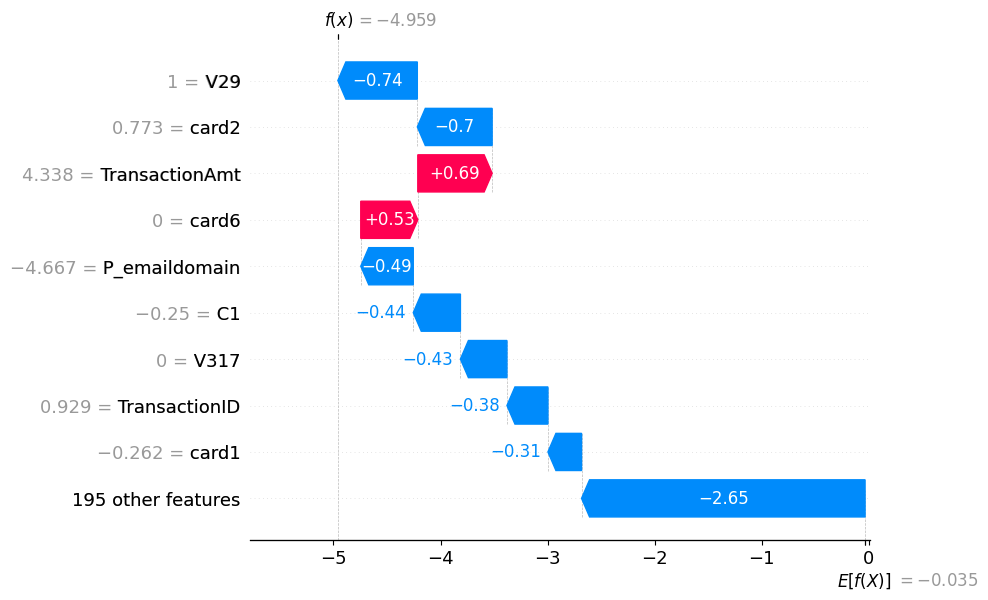

In [57]:
# ==========================================
# STEP 9 Legitimate Waterfall Plot
# ==========================================

shap.plots.waterfall(
    shap_values[legit_position]
)

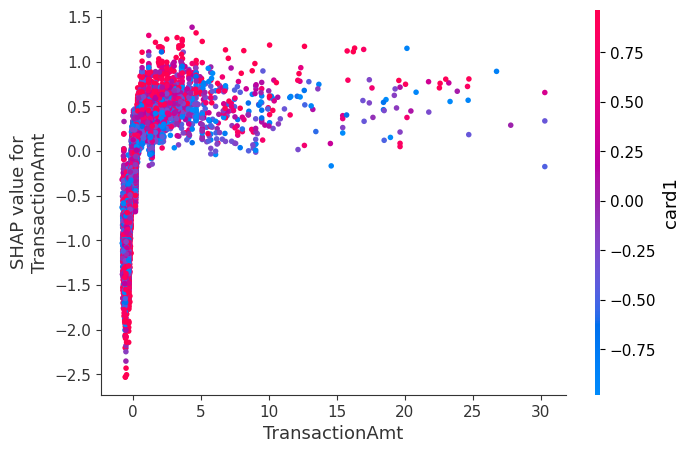

In [58]:
# ==========================================
# STEP 10 SHAP Dependence Plot
# ==========================================

shap.dependence_plot(
    "TransactionAmt",
    shap_values.values,
    X_test_scaled
)

In [59]:
# ==========================================
# STEP 11 Feature Importance
# ==========================================

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(
    feature_importance.head(20)
)

    Feature  Importance
91      V71    0.102534
196    V317    0.092834
16       C4    0.071810
6     card3    0.065269
49      V29    0.046474
159    V280    0.029126
14       C2    0.026264
166    V287    0.022760
167    V288    0.022574
161    V282    0.019010
185    V306    0.016871
123    V103    0.015652
158    V279    0.014969
169    V290    0.014003
9     card6    0.013875
107     V87    0.013558
26      C14    0.013287
173    V294    0.012804
46      V26    0.011610
71      V51    0.011139


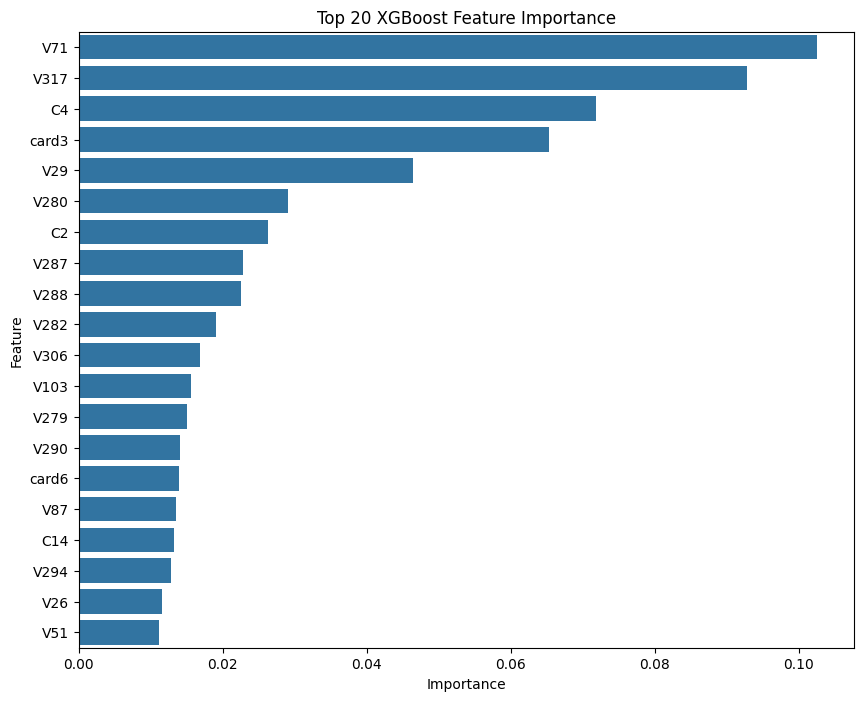

In [60]:
# ==========================================
# STEP 12 Feature Importance Plot
# ==========================================

top_features = feature_importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 XGBoost Feature Importance"
)

plt.savefig(
    "charts/feature_importance.png"
)

plt.show()

# SHAP Summary Plot Interpretation

The SHAP summary plot shows the overall impact of features on fraud prediction across all transactions.

Features at the top have the highest contribution toward the model's predictions.

Positive SHAP values increase fraud probability, while negative SHAP values reduce fraud probability.

The plot also shows how high and low feature values influence prediction behavior across the dataset.

# Fraud Transaction Explanation

The confirmed fraud transaction showed several strong positive SHAP contributions.

Important features significantly increased fraud probability, indicating abnormal transaction behavior compared to legitimate customer activity.

The model identified high-risk behavioral patterns and therefore classified the transaction as fraudulent.

# Borderline Transaction Explanation

The borderline transaction contained both positive and negative SHAP contributions.

Some features increased fraud probability, while others reduced it, resulting in prediction uncertainty near the decision boundary.

This demonstrates how the model handles transactions with partially suspicious behavior.

# Legitimate Transaction Explanation

The legitimate transaction showed mostly negative SHAP contributions.

Most transaction characteristics aligned with normal customer behavior patterns and reduced fraud probability.

Therefore, the model classified the transaction as low risk.

# SHAP Importance vs Feature Importance

Traditional feature importance identifies which features were most useful during model training.

SHAP provides deeper interpretability by:
- explaining individual predictions
- showing contribution direction
- identifying how each feature increases or decreases fraud probability

While feature importance provides global importance ranking, SHAP explains both global model behavior and local transaction-level decisions.

# ==========================================
# TASK 5
# Risk Segmentation & Fraud Analysis
# ==========================================

In [61]:
# ==========================================
# STEP 1 Create Risk DataFrame
# ==========================================

risk_df = X_test.copy()

# Add actual labels

risk_df["ActualFraud"] = y_test.values

# Add fraud probability

risk_df["FraudProbability"] = xgb_prob

print(risk_df.head())

       TransactionID  TransactionDT  TransactionAmt  ProductCD  card1  card2  \
46802        3033802        1114622         522.950          4   7585  553.0   
39213        3026213         954501          28.976          0  15885  545.0   
40278        3027278        1000857         122.950          4  17635  565.0   
5867         2992867         184155          77.000          4  18018  452.0   
30149        3017149         759717          50.000          4  10023  111.0   

       card3  card4  card5  card6  ...  V317  V318  V319  V320  V321  \
46802  150.0      3  226.0      1  ...   0.0   0.0   0.0   0.0   0.0   
39213  185.0      3  138.0      2  ...   0.0   0.0   0.0   0.0   0.0   
40278  150.0      3  226.0      2  ...   0.0   0.0   0.0   0.0   0.0   
5867   150.0      2  117.0      2  ...   0.0   0.0   0.0   0.0   0.0   
30149  150.0      3  226.0      2  ...   0.0   0.0   0.0   0.0   0.0   

       AmtToMeanRatio  HourOfDay  HighAmountFlag  ActualFraud  \
46802        4.081618

In [62]:
# ==========================================
# STEP 2 Create Risk Tiers
# ==========================================

risk_df["RiskTier"] = np.where(

    risk_df["FraudProbability"] >= 0.75,

    "Critical Risk",

    np.where(

        risk_df["FraudProbability"] >= 0.40,

        "Suspicious",

        "Clear"
    )
)

print("Risk Tiers Created")

Risk Tiers Created


In [63]:
# ==========================================
# STEP 3 Risk Tier Counts
# ==========================================

risk_counts = risk_df[
    "RiskTier"
].value_counts()

print(risk_counts)

RiskTier
Clear            9811
Critical Risk     132
Suspicious         57
Name: count, dtype: int64


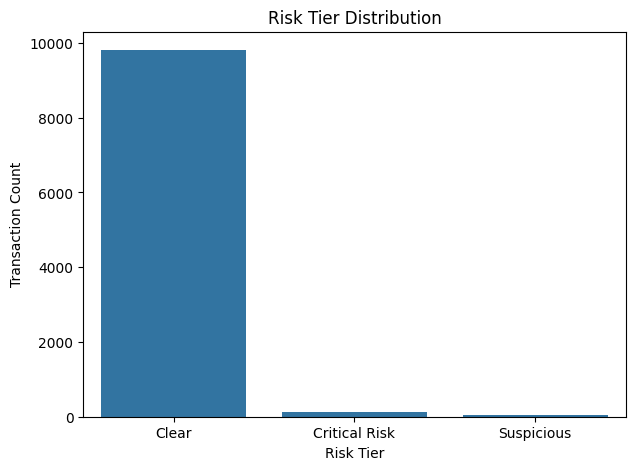

In [64]:
# ==========================================
# STEP 4 Risk Tier Visualization
# ==========================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=risk_df,
    x="RiskTier"
)

plt.title(
    "Risk Tier Distribution"
)

plt.xlabel("Risk Tier")

plt.ylabel("Transaction Count")

plt.savefig(
    "charts/risk_tier_distribution.png"
)

plt.show()

In [65]:
# ==========================================
# STEP 5 Average Transaction Amount
# ==========================================

avg_transaction_amt = risk_df.groupby(
    "RiskTier"
)["TransactionAmt"].mean()

print(avg_transaction_amt)

RiskTier
Clear            130.472625
Critical Risk    126.623015
Suspicious       105.816509
Name: TransactionAmt, dtype: float64


In [66]:
# ==========================================
# STEP 6 Hour Of Day Pattern
# ==========================================

hour_pattern = risk_df.groupby(
    "RiskTier"
)["HourOfDay"].mean()

print(hour_pattern)

RiskTier
Clear            14.119488
Critical Risk    14.462894
Suspicious       12.139162
Name: HourOfDay, dtype: float64


In [67]:
# ==========================================
# STEP 7 Device Type Distribution
# ==========================================

if "DeviceType" in risk_df.columns:

    device_distribution = pd.crosstab(

        risk_df["RiskTier"],

        risk_df["DeviceType"]
    )

    print(device_distribution)

else:

    print(
        "DeviceType column not available"
    )

DeviceType column not available


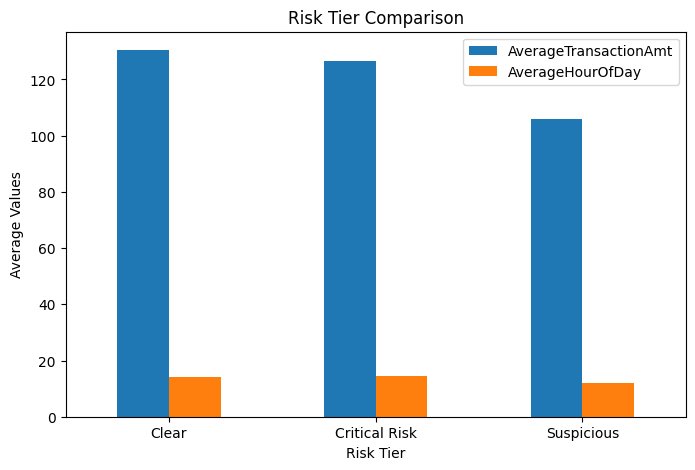

In [68]:
# ==========================================
# STEP 8 Grouped Bar Chart
# ==========================================

comparison_df = pd.DataFrame({

    "AverageTransactionAmt":
        avg_transaction_amt,

    "AverageHourOfDay":
        hour_pattern
})

comparison_df.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Risk Tier Comparison"
)

plt.xlabel("Risk Tier")

plt.ylabel("Average Values")

plt.xticks(rotation=0)

plt.savefig(
    "charts/risk_tier_comparison.png"
)

plt.show()

In [69]:
# ==========================================
# STEP 9 Critical Risk Transactions
# ==========================================

critical_risk_df = risk_df[
    risk_df["RiskTier"]
    == "Critical Risk"
]

print(
    critical_risk_df.head()
)

       TransactionID  TransactionDT  TransactionAmt  ProductCD  card1  card2  \
4092         2991092         162108          83.742          0  10086  500.0   
48935        3035935        1176067          12.709          0   7177  176.0   
22051        3009051         579505         200.000          1   1394  399.0   
35844        3022844         868992          81.970          0  13413  103.0   
26378        3013378         674467          28.156          0   3867  296.0   

       card3  card4  card5  card6  ...   V318  V319  V320  V321  \
4092   185.0      2  224.0      1  ...    0.0   0.0   0.0   0.0   
48935  185.0      2  224.0      1  ...    0.0   0.0   0.0   0.0   
22051  150.0      0  185.0      1  ...  400.0   0.0   0.0   0.0   
35844  185.0      3  137.0      1  ...    0.0   0.0   0.0   0.0   
26378  185.0      3  226.0      1  ...    0.0   0.0   0.0   0.0   

       AmtToMeanRatio  HourOfDay  HighAmountFlag  ActualFraud  \
4092         0.653605  21.030000               1   

In [70]:
# ==========================================
# STEP 10 Top Fraud Patterns
# ==========================================

print(
    "Top 3 Fraud Patterns"
)

# ------------------------------------------
# Pattern 1
# Average Transaction Amount
# ------------------------------------------

print(
    "\n1. Average Transaction Amount"
)

print(
    critical_risk_df[
        "TransactionAmt"
    ].mean()
)

# ------------------------------------------
# Pattern 2
# Most Common Transaction Hour
# ------------------------------------------

print(
    "\n2. Most Common Transaction Hour"
)

print(
    critical_risk_df[
        "HourOfDay"
    ].mode()[0]
)

# ------------------------------------------
# Pattern 3
# Most Common Risk Probability
# ------------------------------------------

print(
    "\n3. Average Fraud Probability"
)

print(
    critical_risk_df[
        "FraudProbability"
    ].mean()
)

Top 3 Fraud Patterns

1. Average Transaction Amount
126.62301515151513

2. Most Common Transaction Hour
0.13333333333332575

3. Average Fraud Probability
0.9210168


# Risk Segmentation Analysis

Transactions were segmented into three categories using fraud probability generated by the XGBoost model.

## Risk Categories

- Critical Risk → Fraud probability greater than or equal to 0.75
- Suspicious → Fraud probability between 0.40 and 0.74
- Clear → Fraud probability below 0.40

## Key Findings

Critical Risk transactions generally showed:
- Higher transaction amounts
- Strong fraud probability scores
- Distinct transaction timing behavior

The analysis helps identify high-priority transactions that require manual investigation and fraud prevention actions.

# Top Fraud Patterns

The analysis of Critical Risk transactions revealed several common fraud characteristics:

1. Transactions often involved higher-than-average transaction amounts.

2. Fraudulent activity showed recurring transaction timing patterns during specific hours of the day.

3. Critical Risk transactions consistently received very high fraud probability scores from the XGBoost model, indicating strong abnormal behavior signals.

In [71]:
# ==========================================
# Save Model Files For Streamlit
# ==========================================

import joblib

# Save trained XGBoost model

joblib.dump(
    xgb_model,
    "dashboard/model.pkl"
)

# Save scaler

joblib.dump(
    scaler,
    "dashboard/scaler.pkl"
)

# Save feature columns

joblib.dump(
    X_train.columns.tolist(),
    "dashboard/feature_columns.pkl"
)

print("Model Files Saved Successfully")

Model Files Saved Successfully


In [72]:
# ==========================================
# Save Dataset For Dashboard
# ==========================================

risk_df.to_csv(
    "dashboard/dashboard_data.csv",
    index=False
)

print("Dashboard Dataset Saved")

Dashboard Dataset Saved


# ==========================================
# TASK 7
# Visualizations
# ==========================================

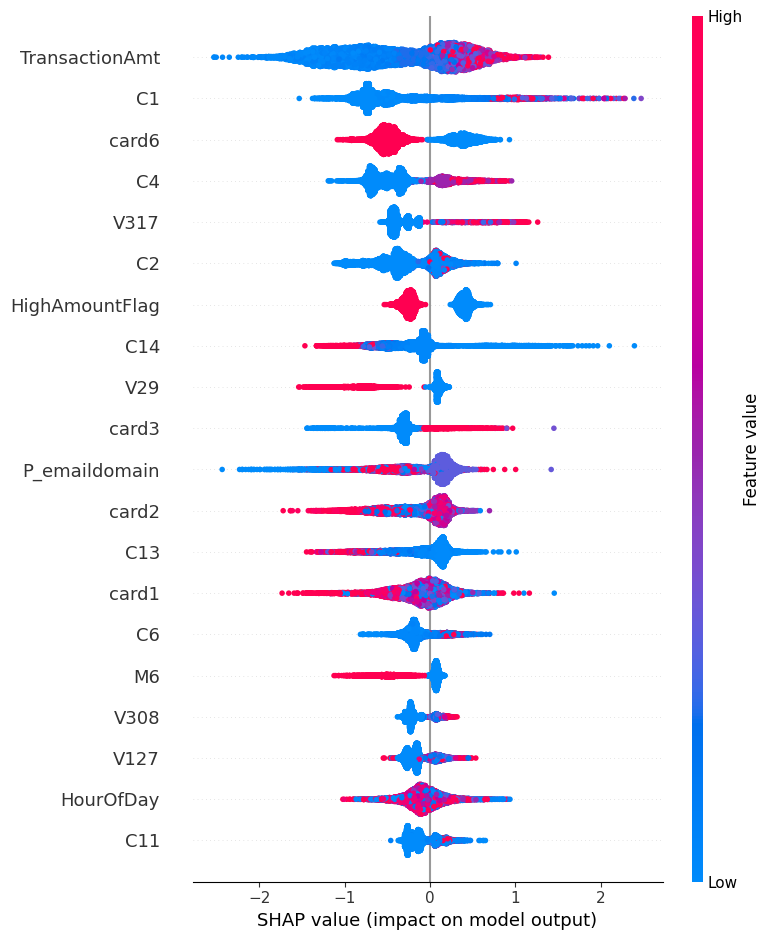

<Figure size 640x480 with 0 Axes>

In [73]:
# ==========================================
# Chart 1
# SHAP Global Summary Plot
# ==========================================

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test_scaled,
    max_display=20
)

plt.savefig(
    "charts/shap_global_summary.png"
)

plt.show()

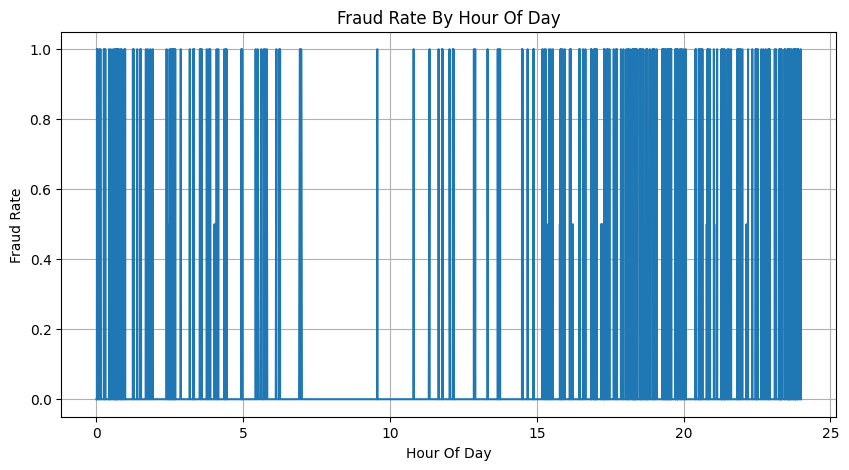

In [74]:
# ==========================================
# Chart 2
# Fraud Rate By Hour Of Day
# ==========================================

fraud_hour = risk_df.groupby(
    "HourOfDay"
)["ActualFraud"].mean()

plt.figure(figsize=(10,5))

fraud_hour.plot()

plt.title(
    "Fraud Rate By Hour Of Day"
)

plt.xlabel("Hour Of Day")

plt.ylabel("Fraud Rate")

plt.grid()

plt.savefig(
    "charts/fraud_rate_by_hour.png"
)

plt.show()

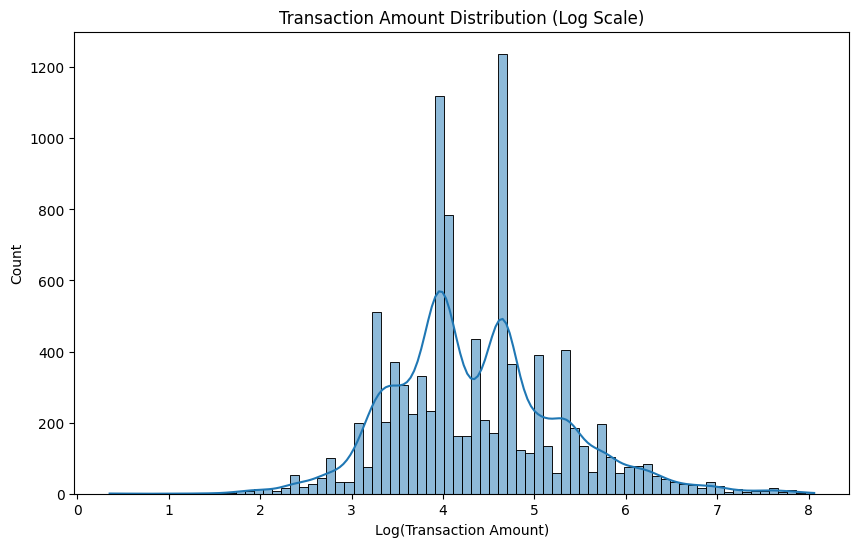

In [75]:
# ==========================================
# Chart 3
# Transaction Amount Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(
        risk_df["TransactionAmt"]
    ),
    kde=True
)

plt.title(
    "Transaction Amount Distribution (Log Scale)"
)

plt.xlabel(
    "Log(Transaction Amount)"
)

plt.savefig(
    "charts/transaction_amount_distribution.png"
)

plt.show()

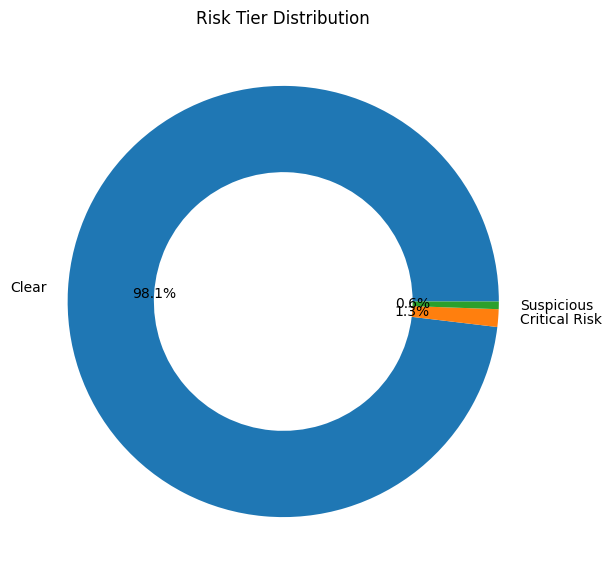

In [76]:
# ==========================================
# Chart 4
# Risk Tier Donut Chart
# ==========================================

risk_counts = risk_df[
    "RiskTier"
].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%1.1f%%",
    wedgeprops={
        "width":0.4
    }
)

plt.title(
    "Risk Tier Distribution"
)

plt.savefig(
    "charts/risk_tier_donut_chart.png"
)

plt.show()

Best Threshold: 0.35216808


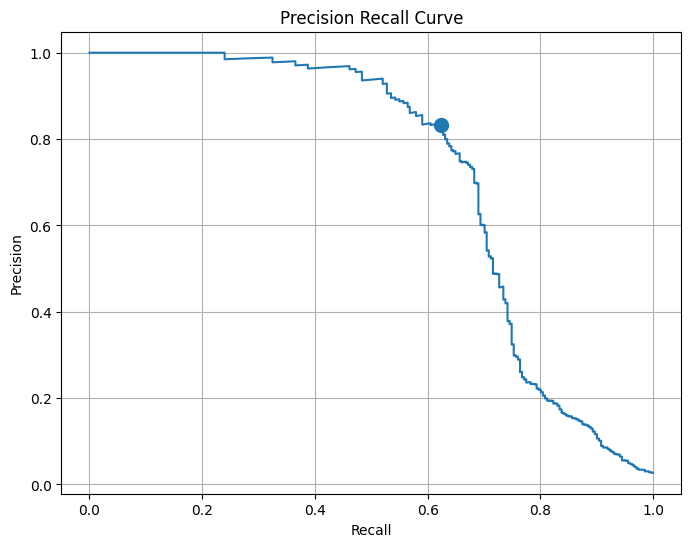

In [77]:
# ==========================================
# Chart 5
# Precision Recall Curve
# ==========================================

from sklearn.metrics import (
    precision_recall_curve
)

precision, recall, thresholds = precision_recall_curve(
    y_test,
    xgb_prob
)

# Calculate F1 Scores

f1_scores = (
    2 * precision * recall
) / (
    precision + recall + 1e-10
)

# Best Threshold

best_threshold_index = np.argmax(
    f1_scores
)

best_threshold = thresholds[
    best_threshold_index
]

print(
    "Best Threshold:",
    best_threshold
)

# Plot

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.scatter(
    recall[best_threshold_index],
    precision[best_threshold_index],
    marker="o",
    s=100
)

plt.title(
    "Precision Recall Curve"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.grid()

plt.savefig(
    "charts/pr_curve_optimal_threshold.png"
)

plt.show()

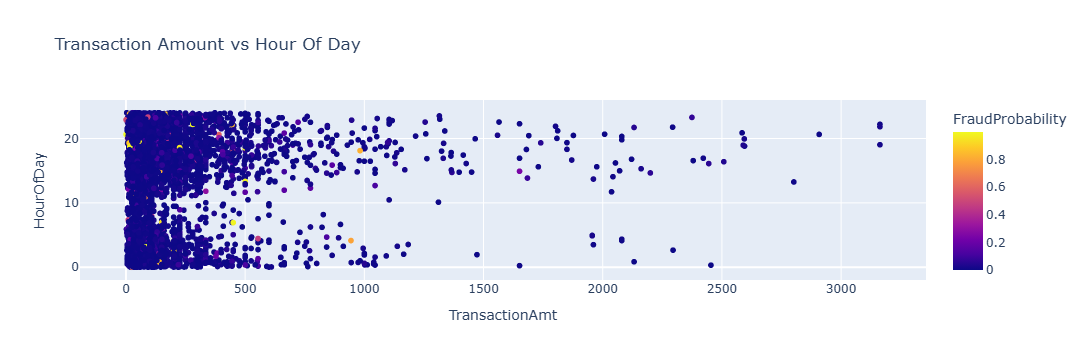

In [78]:
# ==========================================
# Bonus Chart
# Interactive Plotly Scatter Plot
# ==========================================

import plotly.express as px

scatter_fig = px.scatter(

    risk_df,

    x="TransactionAmt",

    y="HourOfDay",

    color="FraudProbability",

    title="Transaction Amount vs Hour Of Day",

    hover_data=[
        "FraudProbability",
        "RiskTier"
    ]
)

scatter_fig.show()

# Visualization Summary

Several visualizations were created to better understand fraud behavior patterns and model performance.

## Key Insights

- SHAP summary plots identified the most influential fraud detection features.
- Fraud activity showed distinct hourly transaction behavior patterns.
- Transaction amount distributions revealed differences between normal and suspicious activity.
- Risk tier segmentation highlighted the proportion of high-risk transactions.
- Precision-Recall analysis helped identify the optimal fraud detection threshold.

Interactive Plotly visualizations further improved exploratory analysis and dashboard usability.

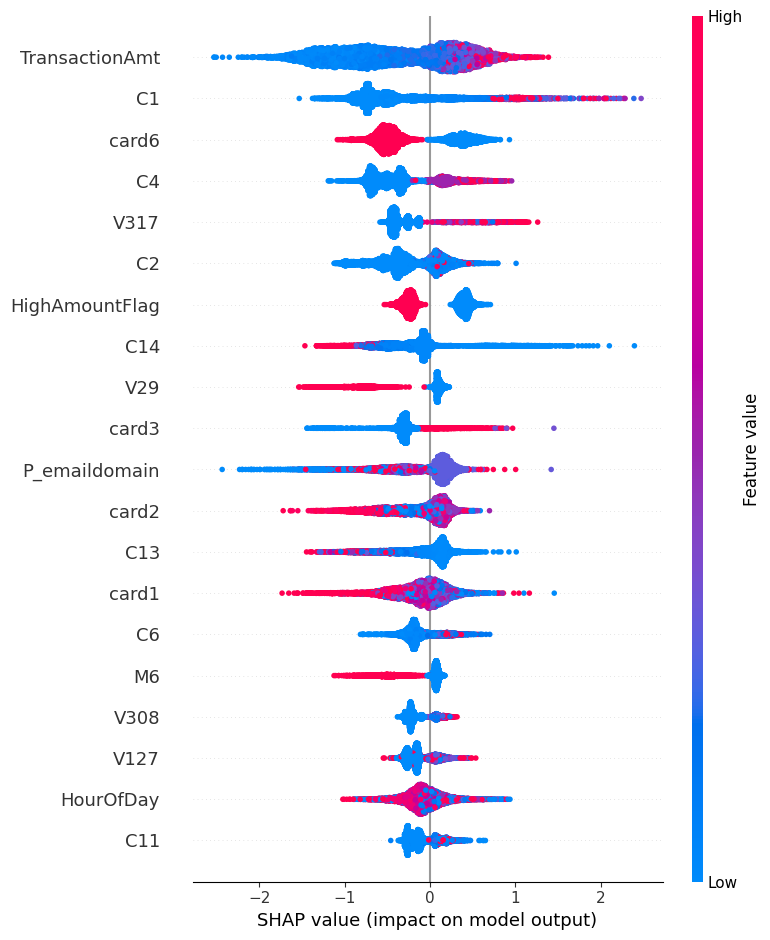

In [82]:
# ==========================================
#  SHAP SUMMARY SAVE
# ==========================================

import shap
import matplotlib.pyplot as plt

# Create figure
fig = plt.figure(figsize=(12,8))

# Generate SHAP summary
shap.summary_plot(
    shap_values,
    X_test_scaled,
    max_display=20,
    show=False
)

# Save BEFORE plt.show()
fig.savefig(
    "shap_summary.png",
    bbox_inches="tight",
    dpi=300
)

# Also save inside charts folder
fig.savefig(
    "charts/shap_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()